In [1]:
import cv2
import numpy as np

lower_red1 = np.array([0, 100, 100])
upper_red1 = np.array([10, 255, 255])

lower_red2 = np.array([160, 100, 100])
upper_red2 = np.array([180, 255, 255])

lower_green = np.array([35, 50, 50])
upper_green = np.array([85, 255, 255])
width, height = 640, 480

def get_thing(frame):
    savszel = width // 4
    sav1 = [0, savszel]
    sav2 = [savszel, savszel*2]
    sav3 = [savszel*2, savszel*3]
    sav4 = [savszel*3, width]

    G_sav = frame[:, savszel:savszel*3]

    hsv = cv2.cvtColor(G_sav, cv2.COLOR_BGR2HSV)

    mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
    mask2 = cv2.inRange(hsv, lower_red2, upper_red2)
    mask3 = cv2.inRange(hsv, lower_green, upper_green)

    RedInMask = cv2.countNonZero(mask1) + cv2.countNonZero(mask2)
    GreenInMask = cv2.countNonZero(mask3)
    if RedInMask > 4000 or GreenInMask > 4000:
        if RedInMask > GreenInMask:
            return "Red"
        else:
            return "Green"
    elif RedInMask < 4000 and GreenInMask < 4000:
        return 0


[1:05:00.627967846] [6930]  INFO Camera camera_manager.cpp:340 libcamera v0.7.0+rpt20260205
[1:05:00.651998757] [6937]  INFO IPAProxy ipa_proxy.cpp:180 Using tuning file /usr/share/libcamera/ipa/rpi/vc4/imx219.json
[1:05:00.657247985] [6937]  INFO Camera camera_manager.cpp:223 Adding camera '/base/soc/i2c0mux/i2c@1/imx219@10' for pipeline handler rpi/vc4
[1:05:00.657297909] [6937]  INFO RPI vc4.cpp:445 Registered camera /base/soc/i2c0mux/i2c@1/imx219@10 to Unicam device /dev/media3 and ISP device /dev/media0
[1:05:00.657327668] [6937]  INFO RPI pipeline_base.cpp:1117 Using configuration file '/usr/share/libcamera/pipeline/rpi/vc4/rpi_apps.yaml'
[1:05:00.667555706] [6930]  INFO Camera camera.cpp:1215 configuring streams: (0) 640x480-XRGB8888/sRGB (1) 640x480-SBGGR10_CSI2P/RAW
[1:05:00.668227963] [6937]  INFO RPI vc4.cpp:620 Sensor: /base/soc/i2c0mux/i2c@1/imx219@10 - Selected sensor format: 640x480-SBGGR10_1X10/RAW - Selected unicam format: 640x480-pBAA/RAW


Dolog: Red


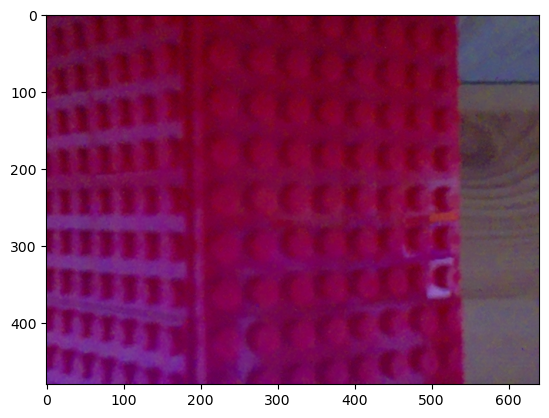

In [4]:
from matplotlib import pyplot as plt
from picamera2 import Picamera2


cam = Picamera2()

cam.configure(
    cam.create_preview_configuration(
        main={"format": 'XRGB8888', "size": (width, height)}, display=None))
cam.start()
caparr = cam.capture_array()
thing = get_thing(caparr)
print(f"Dolog: {thing}")
plt.imshow(caparr[:, :, 2::-1])
plt.show()
cam.stop()
cam.close()